<a href="https://colab.research.google.com/github/loki20051267/hpc-project/blob/main/paper17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 30.6 MB/s eta 0:00:00
Using: cpu
Class distribution: tensor([10825, 10825])
Epoch 0 | Loss 120.2541 | Acc 0.7921
Epoch 1 | Loss 103.6242 | Acc 0.8289
Epoch 2 | Loss 99.8209 | Acc 0.8377
Epoch 3 | Loss 97.9807 | Acc 0.8380
Epoch 4 | Loss 97.0281 | Acc 0.8378
Epoch 5 | Loss 96.5924 | Acc 0.8398
Epoch 6 | Loss 96.4164 | Acc 0.8402
Epoch 7 | Loss 95.8413 | Acc 0.8412
Epoch 8 | Loss 95.6216 | Acc 0.8425
Epoch 9 | Loss 95.2222 | Acc 0.8417
Epoch 10 | Loss 95.1705 | Acc 0.8413
Epoch 11 | Loss 94.5340 | Acc 0.8417
Epoch 12 | Loss 94.8082 | Acc 0.8426
Epoch 13 | Loss 94.5882 | Acc 0.8420
Epoch 14 | Loss 94.2369 | Acc 0.8442
Epoch 15 | Loss 94.1575 | Acc 0.8428
Epoch 16 | Loss 94.3978 | Acc 0.8429
Epoch 17 | Loss 93.5878 | Acc 0.8433
Epoch 18 | Loss 93.8743 | Acc 0.8421
Epoch 19 | Loss 93.5861 | Acc 0.8454

🔥 TEST ACCURACY: 0.8357967734336853


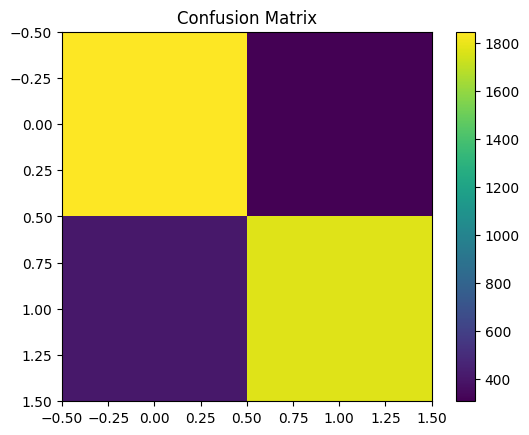

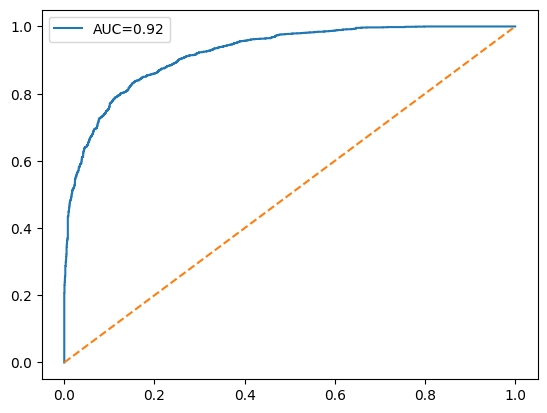

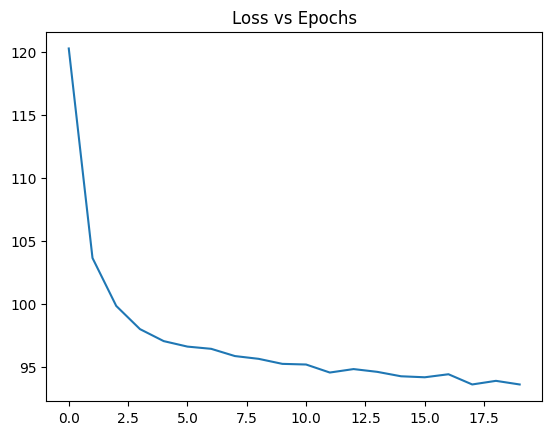

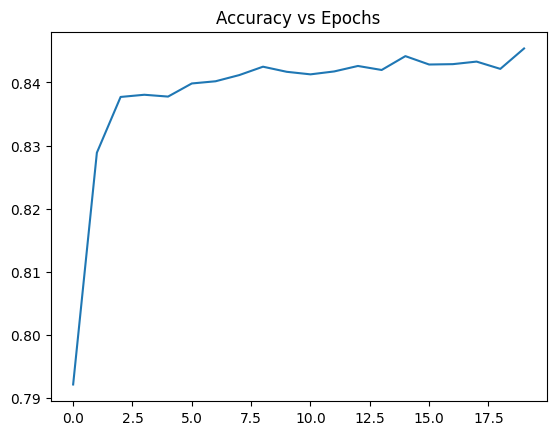

In [1]:
# ==============================
# INSTALL
# ==============================
!pip install torch torchvision torchaudio -q
!pip install torch-geometric scikit-learn -q

# ==============================
# IMPORTS
# ==============================
import torch
import torch.nn as nn
import pandas as pd
import numpy as np

from torch_geometric.nn import GCNConv
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample

import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

# ==============================
# DEVICE
# ==============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

# ==============================
# LOAD DATA (UPDATED FILES)
# ==============================
file1 = "/content/S17S1.csv"
file2 = "/content/S17S2.csv"

data = pd.concat([pd.read_csv(file1), pd.read_csv(file2)], axis=0)

X = data.iloc[:, :-1].values
y_raw = data.iloc[:, -1].values

# ==============================
# LABELING (balanced)
# ==============================
y = (y_raw > np.mean(y_raw)).astype(int)

# ==============================
# NORMALIZATION
# ==============================
scaler = StandardScaler()
X = scaler.fit_transform(X)

# ==============================
# CLASS BALANCING
# ==============================
df = pd.DataFrame(X)
df['label'] = y

majority = df[df.label == 0]
minority = df[df.label == 1]

minority = resample(minority,
                   replace=True,
                   n_samples=len(majority),
                   random_state=42)

df = pd.concat([majority, minority])

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# ==============================
# TO TENSOR
# ==============================
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.long)

print("Class distribution:", torch.bincount(y))

# ==============================
# GRAPH
# ==============================
num_nodes = X.shape[1]

edges = []
for i in range(num_nodes - 1):
    edges.append([i, i+1])
    edges.append([i+1, i])

edge_index = torch.tensor(edges).t().contiguous().to(device)

# ==============================
# SPLIT
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# ==============================
# DATALOADER
# ==============================
train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=64,
    shuffle=True
)

# ==============================
# MODEL
# ==============================
class TGNN(nn.Module):
    def __init__(self, num_features):
        super().__init__()

        self.gcn1 = GCNConv(1, 64)
        self.gcn2 = GCNConv(64, 32)

        self.dropout = nn.Dropout(0.3)

        self.lstm = nn.LSTM(32 * num_features, 64, batch_first=True)

        self.fc = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 2)
        )

    def forward(self, x):
        batch_size, num_features = x.shape
        x = x.unsqueeze(-1)

        out_list = []
        for i in range(batch_size):
            xi = x[i]
            xi = torch.relu(self.gcn1(xi, edge_index))
            xi = torch.relu(self.gcn2(xi, edge_index))
            xi = self.dropout(xi)
            out_list.append(xi.flatten())

        x = torch.stack(out_list).unsqueeze(1)
        x, _ = self.lstm(x)
        x = x.squeeze(1)

        return self.fc(x)

# ==============================
# INIT
# ==============================
model = TGNN(X.shape[1]).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# ==============================
# TRAIN
# ==============================
epochs = 20

loss_list = []
acc_list = []

for epoch in range(epochs):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        output = model(xb)
        loss = criterion(output, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, pred = torch.max(output, 1)
        correct += (pred == yb).sum().item()
        total += yb.size(0)

    acc = correct / total

    loss_list.append(total_loss)
    acc_list.append(acc)

    print(f"Epoch {epoch} | Loss {total_loss:.4f} | Acc {acc:.4f}")

# ==============================
# TEST
# ==============================
model.eval()

X_test = X_test.to(device)
y_test = y_test.to(device)

with torch.no_grad():
    output = model(X_test)
    probs = torch.softmax(output, dim=1)[:,1]
    _, pred = torch.max(output, 1)

test_acc = (pred == y_test).float().mean().item()
print("\n🔥 TEST ACCURACY:", test_acc)

# ==============================
# CONFUSION MATRIX
# ==============================
cm = confusion_matrix(y_test.cpu(), pred.cpu())

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.savefig("confusion_matrix.png")
plt.show()

# ==============================
# ROC
# ==============================
fpr, tpr, _ = roc_curve(y_test.cpu(), probs.cpu())
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC={roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.savefig("roc_curve.png")
plt.show()

# ==============================
# LOSS GRAPH
# ==============================
plt.plot(loss_list)
plt.title("Loss vs Epochs")
plt.savefig("loss.png")
plt.show()

# ==============================
# ACCURACY GRAPH
# ==============================
plt.plot(acc_list)
plt.title("Accuracy vs Epochs")
plt.savefig("accuracy.png")
plt.show()